<h3>Importing my development version of ShadowGrouping</h3>

In [1]:
import sys, numpy as np, time, pickle
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
import matplotlib.pyplot as plt
from IPython.display import Image, display
from os import mkdir
from os.path import isdir, isfile

# adding ShadowGrouping package to the system path
# SG_package_path = r"G:\\My Drive\\Work\\Research\\Numerics\\ShadowGrouping Code\\"
#SG_package_path = r"C:\Users\aebad\shadowgrouping\\"
SG_package_path = r"C:\Users\Abbas\Priori\\"
sys.path.insert(0, SG_package_path)
#savename = ".txt" # insert {mapping_name}
savepath = "generated_data/random_Hamiltonians/"
# defining path where Hamiltonians are stored
folder_Hamiltonians = SG_package_path + "Hamiltonians_v2\\"

In [2]:
from shadowgrouping_v2.measurement_schemes import L1_sampler, Derandomization
#from shadowgrouping.measurement_schemes import Shadow_Grouping
from shadowgrouping.measurement_schemes_Shadowupdate import Priori, Posteriori, Shadow_Grouping, Best_scheme_given_pool
from shadowgrouping_v2.weight_functions import Bernstein_bound
from shadowgrouping_v2.energy_estimator import Energy_estimator, StateSampler, Sign_estimator
from shadowgrouping_v2.helper_functions import (
    setting_to_str, char_to_int, int_to_char, settings_to_dict, prepare_settings_for_numba, gaussian_weights, gaussian_random_paulis, uniform_weights, uniform_random_paulis,
    sample_obs_from_setting, setting_to_str, setting_to_obs_form, sample_obs_batch_from_setting_batch, sample_obs_batch_from_setting_batch_numba, bootstrap_rmse)
from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state
from shadowgrouping_v2.guarantees import (
    get_epsilon_Bernstein, get_epsilon_Bernstein_no_restricted_validity, 
    get_epsilon_Bernstein_tighter, get_epsilon_Bernstein_tighter_no_restricted_validity, 
    get_epsilon_Bernstein_scalar, get_epsilon_Bernstein_scalar_no_restricted_validity,
    get_epsilon_Bernstein_scalar_tighter, get_epsilon_Bernstein_scalar_tighter_no_restricted_validity, 
    get_epsilon_Hoeffding_scalar, get_epsilon_Hoeffding_scalar_tighter, get_epsilon_Chebyshev_scalar, 
    get_epsilon_Chebyshev_scalar_tighter, get_epsilon_single_Hoeffding_plus_union_bound,
    get_epsilon_Chebyshev_scalar_numba, get_epsilon_Chebyshev_scalar_tighter_numba,
    get_epsilon_Hoeffding_scalar_numba, get_epsilon_Hoeffding_scalar_tighter_numba)
from guarantees.exact_covariances import covariance_matrix
from guarantees.guarantees import (get_epsilon_Chebyshev_scalar_tighter_numba, get_epsilon_Chebyshev_scalar_tightest_numba)
from shadowgrouping.poolgenerators import Priori_Pool , OGM_Pool, AEQUO_Pool

C:\Users\Abbas\AppData\Local\Temp\ipykernel_11452\3627826541.py:9: NatureDeprecationWarning: The qiskit_nature.drivers.second_quantization package is deprecated as of version 0.5.0 and will be removed no sooner than 3 months after the release. Instead use the qiskit_nature.second_q.drivers package.
  from shadowgrouping_v2.hamiltonian import get_pauli_list, get_groundstate, mappings, load_pauli_list, apply_Hamiltonian_to_state


<h3>Choosing molecule, basis set and fermion-to-qubit mapping</h3>

In [3]:
molecule_name = "BeH2" # choose one out of the molecules ['H2', 'H2_6-31g', 'LiH', 'BeH2', 'H2O', 'NH3']
mapping_name = "JW" # choose one out of ["JW","BK","Parity"]
if molecule_name == 'H2':
    basis_set = "6-31g"
else:
    basis_set = "sto3g"
num_qubits = {'H2': 8, 'LiH': 12, 'BeH2': 14, 'H2O': 14, "NH3": 16} # number of qubits in which Hamiltonian is defined
savename = molecule_name + "_molecule_" + mapping_name + "_" + basis_set
folder_OGM_settings = "OGM_probabilities/OGM_{}_{}{}.txt" # format string to fill in {molecule}x{qubit_number}x{mapping}

<h3>Import the original hamiltonian file</h3>

In [4]:
# ensure the folder exists
import os


assert os.path.isdir(folder_Hamiltonians), f"Path '{folder_Hamiltonians}' does not exist or is not a directory."
    # find folder matching molecule + basis name
available_folders = os.listdir(folder_Hamiltonians)
prefix = f"{molecule_name}_{basis_set}"
folder_name = None
for folder in available_folders:
    if folder.startswith(prefix):
        folder_name = folder
        break

assert folder_name is not None, f"File not found for molecule '{molecule_name}' and basis set '{basis_set}'."
full_folder_path = os.path.join(folder_Hamiltonians, folder_name)

    # look for encoding and energy file
available_files = os.listdir(full_folder_path)
    
    #print(f"full path to folder",full_folder_path)
file_name = None
file_energy = None
for file in available_files:
    if file.lower().startswith(mapping_name[:2].lower()) and "grouped" not in file:
        file_name = file
    elif file == "ExactEnergy.txt":
        file_energy = file

assert file_name is not None, f"File not found for encoding '{mapping_name}'."
assert file_energy is not None, "File not found for ground-state energy."
    
print(f"full path to file",os.path.join(full_folder_path, file_name))

full path to file C:\Users\Abbas\Priori\\Hamiltonians_v2\BeH2_sto3g_14qubits\jw.txt


<h3>Loading Prior Information</h3>

In [5]:
# Loading Hamiltonian
observables, w, offset, E_GS, state = load_pauli_list(folder_Hamiltonians,molecule_name,basis_set,mapping_name,diagonalize=False)

# loading exact ground state
path_to_GS = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\exact_gs.txt"
with open(path_to_GS, 'r') as f:
    data_string = f.read()
state = data_string.split('\n')
state = state[:len(state)-1]
for i in range(len(state)):
    state[i] = complex(state[i])
state = np.array(state)

# Loading exact ground state energy
path_to_GS_energy = folder_Hamiltonians + molecule_name + "_" + basis_set + "_" + str(num_qubits[molecule_name]) + "qubits\\exact_gs_energy.txt"
with open(path_to_GS_energy, 'r') as f:
    data_string = f.read()
E_GS = float(data_string)

# Calculating exact covariances

sanity = True
tightest = True

if tightest:
        # Computing exact representation of full covariance matrix
        exact_covariances = covariance_matrix(state, observables)
        #print(np.round(exact_covariances,3))
        cov_real = np.ascontiguousarray(((exact_covariances + exact_covariances.conj().T).real) * 0.5, dtype=np.float64)
"""if sanity:
        # Sanity check: Computing total variance using full matrix representation of Hamiltonian
        H_dot_state = apply_Hamiltonian_to_state(state, molecule_name, basis_set, mapping_name, folder_Hamiltonians)
        exp_value_H2 = np.dot(np.conjugate(H_dot_state), H_dot_state)
        exp_value_H = np.dot(np.conjugate(state), H_dot_state)
        var_H = exp_value_H2 - exp_value_H**2
        print(f"Total variance: {var_H}") # Should be zero since state is an exact eigenstate of Hamiltonian"""

'if sanity:\n        # Sanity check: Computing total variance using full matrix representation of Hamiltonian\n        H_dot_state = apply_Hamiltonian_to_state(state, molecule_name, basis_set, mapping_name, folder_Hamiltonians)\n        exp_value_H2 = np.dot(np.conjugate(H_dot_state), H_dot_state)\n        exp_value_H = np.dot(np.conjugate(state), H_dot_state)\n        var_H = exp_value_H2 - exp_value_H**2\n        print(f"Total variance: {var_H}") # Should be zero since state is an exact eigenstate of Hamiltonian'

<h3>Setting Parameters for Simulation</h3>

In [6]:
Nreps = 100
eps = 0.1
delta = 0.33
Nrounds = 10000
alpha = np.max(np.abs(w))/np.min(np.abs(w)) + np.min(np.abs(w))
state_sampler = StateSampler(state)

<h3>Generating measurement scheme using Shadow_Grouping OR Priori<h3>

In [7]:
label = "AEP" # Select the pool generation method: "SGP" for Shadow Grouping, "PP" for Priori_Pool, "OGMP" for Overlapped Grouping.
if label == "SGP":
    Nreps_SGP = 1
    Nrounds_SGP = 100000
    method_1 = Shadow_Grouping(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP)
    estimator_1.reset()
    t_init_scheme_1 = time.time()
    estimator_1.propose_next_settings(Nrounds_SGP)
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    #print("Keys in settings_dict: ", list(estimator_1.measurement_scheme.settings_dict.keys()))    
    print("Number of hits for each observable: ", estimator_1.measurement_scheme.N_hits)

if label == "PP":
    t_init_scheme_1 = time.time()
    method_1 = Priori_Pool(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)
    
if label == "OGMP":
    t_init_scheme_1 = time.time()
    # catch exception of missing data for OGM
    file = folder_OGM_settings.format(molecule_name,observables.shape[1],mapping_name.lower())
    if isfile(file):
        method_1 = OGM_Pool(observables,w,file)
        method_1.find_setting()
        t_end_scheme_1 = time.time()
        print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
        print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
        print(method_1.N_hits)
    else:
        print(f"File not found for OGM probabilities: {file}. Please run the OGM pool generation code to generate the required data.")


if label == "AEP":
    t_init_scheme_1 = time.time()
    method_1 = AEQUO_Pool(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    method_1.find_setting()
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(method_1.settings_dict.keys())))
    print(method_1.N_hits)

Pool of settings is constructed)
Elapsed time in seconds:  1.899359941482544
Number of different measurement settings:  152
[ 42  41  68  79   7   7  93   6   6  11  12 125 124  84  70  66  38  40
   7   6  78   6   6  91  10  10 125 124  82  74   1   1   1   1  55   6
   6   1   1   1   1  57   2   2   2   2   2   2   1   1   1   1   2   2
   2   1   3   3   1   1   1   1  35  35  46   2   3   5   4   1   1   1
   1   7   8   6   6   1   1   1   1  29   2   2   2   3   2   2   3   3
   3   2  13   1   1   1   1   3   2   3   2   2   2   1   3   2   3   1
   1   1   1   1   1   1   1  41  24  25  12  11   4   4  22  21   1   1
   2   1   6   4   4   4   3   8   2   2   2   2  32  33   4   4  35  35
   3   3   3   3  38   1   1   1   1  23  23   1   1   1   1  26  27  57
   3   3   3   3  18  17  40   1   1   1   1  55   1   1   1   1  32  33
   6   6  30  16  18   1   2  12  12  18  17   2   2   7   8   3   1  11
  13  11  12  10  10   2   1   1   2  46  10  10  32   5   6  22  21  64


<h3>Generating QWC measurement scheme using "Best_scheme_given_pool"<h3>

In [8]:
t_init_scheme_1re = time.time()
method_1re = Best_scheme_given_pool(observables,w,method_1,eps,
                                    total_rounds=Nrounds,is_overlapping=True,
                                    commutativity_type="qwc", # 'qwc', 'fc' or 'kc' 
                                    informed_allocation=True,
                                    allocation_objective="bernstein_l1", # 'variance' or 'bernstein_l1'
                                    attempt_truncation=False,
                                    rounding_strategy="largest_fraction", # 'largest_fraction' or 'marginal'
                                    md_gap_tol_rel=1e-4)
estimator_1re = Energy_estimator(method_1re,state_sampler,offset=offset,N_reps_exp=Nreps,
                                 compat_type='qwc', qubit_connectivity=None)
t_end_scheme_1re = time.time()
print("Elapsed time in seconds: ", t_end_scheme_1re - t_init_scheme_1re)
print("Number of different measurement settings: ", len(list(estimator_1re.measurement_scheme.settings_dict.keys())))
print(estimator_1re.measurement_scheme.N_hits)
epsilonbernstein_1re , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1re.measurement_scheme.N_hits, w, estimator_1re.measurement_scheme.settings_dict)
print(f"Epsilon Bernstein for RE: {epsilonbernstein_1re}")
epsilonchebyshevtighter_1re = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w)
print(f"Epsilon Chebyshev (tighter) for RE: {epsilonchebyshevtighter_1re}")
epsilonchychev_tightest_1re = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1re.measurement_scheme.N_hits, estimator_1re.measurement_scheme.N_hits_pairs, w, cov_real)
print(f"Epsilon Chebyshev (tightest) for RE: {epsilonchychev_tightest_1re}")
estimator_1re.clear_outcomes()
estimator_1re.state = StateSampler(state)
estimator_1re.measure_and_get_running_avgs()
energy_estimates = estimator_1re.get_energy()
rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(energy_estimates, E_GS, n_boot=20000, ci=0.67)
print(f"Results for RE | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")

Updated N_reps_exp to 100. Cleared outcomes using clear_outcomes().
Elapsed time in seconds:  1.2686474323272705
Number of different measurement settings:  137
[3321 3077 4753 5619  535  516 5878  500  483 1042 1110 8399 8613 5903
 5653 4721 3152 3223  494  478 5288  571  568 5849  929  854 8399 8613
 5485 5871   83   85   55   84 3796  500  483   61   61   61   55 4150
  137  139  136  138  244  219   57   57   56   57  226  199  192   93
  193  218   71   99   95  101 3005 2790 3425  166  181  741  329   72
   86   82   49  631  835  500  483   40   40   40   40 2427  118  118
  118  155  154  225  371  377  210  181 1358   48   70   67   45  279
  190  287  199  191  148   61  243  131  462   69   70   69   70   91
   50   50  129 2730 1776 1765 1035  806  309  335 1479 1294   60  105
  240  255  703  384  245  463  283  673  139  120  117  174 2649 2401
  324  473 3005 2790  272  367  251  431 2759   98   93   83   65 1794
 1880   54   54   54   81 2262 2131 4150  211  209  241  24

[Qibo 0.1.11|INFO|2026-05-27 18:04:32]: Using numpy backend on /CPU:0


RuntimeError: Decoded QWC token contains observables that are not all hit by the reconstructed product basis.

<h3>Compare to ShadowGrouping<h3>

In [ ]:
Test = "Y" # If you want to compare the results with the ShadowGrouping, set Test to "Y" otherwise set it to "N"
if Test == "Y":
    method = Shadow_Grouping(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps_SGP)
    estimator.reset()
    t_init_scheme = time.time()
    estimator.propose_next_settings(Nrounds_SGP)
    t_end_scheme = time.time()
    print("Elapsed time in seconds: ", t_end_scheme - t_init_scheme)
    print("Number of different measurement settings: ", len(list(estimator.measurement_scheme.settings_dict.keys())))
    #print("Keys in settings_dict: ", list(estimator.measurement_scheme.settings_dict.keys()))    
    print("Number of hits for each observable: ", estimator.measurement_scheme.N_hits)
    #print("Indices of settings: ", estimator.measurement_scheme.setting_indices)
    epsilonbernstein , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator.measurement_scheme.N_hits, w, estimator.measurement_scheme.settings_dict)
    print(f"Epsilon Bernstein for Shadow Grouping: {epsilonbernstein}")
    epsilonchebyshevtighter = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w)
    print(f"Epsilon Chebyshev (tighter) for Shadow Grouping: {epsilonchebyshevtighter}")
    epsilonchychev_tightest = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w, cov_real)
    print(f"Epsilon Chebyshev (tightest) for Shadow Grouping: {epsilonchychev_tightest}")
    estimator.clear_outcomes()
    estimator.state = StateSampler(state)
    estimator.measure_and_get_running_avgs()
    energy_estimates = estimator.get_energy()
    rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(energy_estimates, E_GS, n_boot=20000, ci=0.67)
    print(f"Results for ShadowGrouping | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
else:
    raise SystemExit("Execution stopped at this cell.")

<h3>Stop Execution</h3>

In [ ]:
raise SystemExit("Execution stopped at this cell.")

SystemExit: Execution stopped at this cell.

c:\Users\Abbas\Priori\.shadowgrouping_env\Lib\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
method_1 = Priori(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator_1 = Energy_estimator(method_1,state_sampler,offset=offset,N_reps_exp=Nreps)
    estimator_1.reset()
    t_init_scheme_1 = time.time()
    estimator_1.propose_next_settings(Nrounds)
    t_end_scheme_1 = time.time()
    print("Elapsed time in seconds: ", t_end_scheme_1 - t_init_scheme_1)
    print("Number of different measurement settings: ", len(list(estimator_1.measurement_scheme.settings_dict.keys())))
    print(estimator_1.measurement_scheme.N_hits)
    epsilonbernstein , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator_1.measurement_scheme.N_hits, w, estimator_1.measurement_scheme.settings_dict)
    print(f"Epsilon Bernstein for Priori: {epsilonbernstein}")
    epsilonchebyshevtighter = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w)
    print(f"Epsilon Chebyshev (tighter) for Priori: {epsilonchebyshevtighter}")
    epsilonchychev_tightest = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator_1.measurement_scheme.N_hits, estimator_1.measurement_scheme.N_hits_pairs, w, cov_real)
    print(f"Epsilon Chebyshev (tightest) for Priori: {epsilonchychev_tightest}")
    estimator_1.clear_outcomes()
    estimator_1.state = StateSampler(state)
    estimator_1.measure_and_get_running_avgs()
    energy_estimates = estimator_1.get_energy()
    rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(energy_estimates, E_GS, n_boot=20000, ci=0.67)
    print(f"Results for Priori | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")

IndentationError: unexpected indent (2433973157.py, line 2)

<h3>Generating random hamiltonains and sampling for ShadowGrouping and Priori</h3>

In [ ]:
Nrandom = 100
t_1 = time.time()
Nreps = 100
eps = 0.1
delta = 0.33
Nrounds = 1000
rmse_values_shadow = []
rmse_stds_shadow = []
rmse_values_priori = []
rmse_stds_priori = []
epsilonbernstein_shadow = []
epsilonbernstein_priori = []
epsilonchebyshevtighter_shadow = []
epsilonchychev_tightest_shadow = []
epsilonchebyshevtighter_priori = []
epsilonchychev_tightest_priori = []
sum_eps_chebyshev_tighter_shadow = np.zeros(Nrounds)
sum_eps_chebyshev_tighter_priori = np.zeros(Nrounds)
sum_eps_bernstein_shadow = np.zeros(Nrounds)
sum_eps_bernstein_priori = np.zeros(Nrounds)
sum_eps_chebyshev_tightest_shadow = np.zeros(Nrounds)
sum_eps_chebyshev_tightest_priori = np.zeros(Nrounds)
sanity = True
tightest = True
for i in range(Nrandom):
    print(f"Round {i+1}")
    # 1. generate random Hamiltonian
    #gaussian_weights(os.path.join(full_folder_path, file_name), center=1.0, width=0.0)
    gaussian_random_paulis(os.path.join(full_folder_path, file_name), avg_support=2.0, std_support=0.8)
    #uniform_weights(os.path.join(full_folder_path, file_name), low=-1, high=1)
    #uniform_random_paulis(os.path.join(full_folder_path, file_name), avg_support=5.8, std_support=1.0)
    # 2. Load pauli list and extract the exact ground state energy and state
    observables, w, offset, E_GS, state = load_pauli_list(folder_Hamiltonians,molecule_name,basis_set,mapping_name, verbose=False, diagonalize=True)
    if tightest:
        # Computing exact representation of full covariance matrix
        exact_covariances = covariance_matrix(state, observables)
        #print(np.round(exact_covariances,3))
        cov_real = np.ascontiguousarray(((exact_covariances + exact_covariances.conj().T).real) * 0.5, dtype=np.float64)
    if sanity:
        # Sanity check: Computing total variance using full matrix representation of Hamiltonian
        H_dot_state = apply_Hamiltonian_to_state(state, molecule_name, basis_set, mapping_name, folder_Hamiltonians)
        exp_value_H2 = np.dot(np.conjugate(H_dot_state), H_dot_state)
        exp_value_H = np.dot(np.conjugate(state), H_dot_state)
        var_H = exp_value_H2 - exp_value_H**2
        print(f"Total variance: {var_H}") # Should be zero since state is an exact eigenstate of Hamiltonian
    alpha = np.max(np.abs(w))/np.min(np.abs(w)) + np.min(np.abs(w))
    # 3. first try Shadow Grouping
    state_sampler = StateSampler(state)
    method = Shadow_Grouping(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator = Energy_estimator(method,state_sampler,offset=offset,N_reps_exp=Nreps)
    estimator.reset()
    estimator.propose_next_settings(Nrounds)
    vals_chebyshev_tighter_shadow = estimator.measurement_scheme.eps_chebyshev_tighter
    sum_eps_chebyshev_tighter_shadow += np.array(vals_chebyshev_tighter_shadow)
    vals_bernstein_shadow = estimator.measurement_scheme.eps_values_v3
    sum_eps_bernstein_shadow += np.array(vals_bernstein_shadow)
    vals_chebyshev_tighter_shadow = estimator.measurement_scheme.eps_chebyshev_tighter
    sum_eps_chebyshev_tightest_shadow += np.array(estimator.measurement_scheme.eps_chebyshev_tightest)
    epsilonbernstein , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator.measurement_scheme.N_hits, w, estimator.settings_dict)
    print(f"Epsilon Bernstein for Shadow Grouping: {epsilonbernstein}")
    epsilonbernstein_shadow.append(epsilonbernstein)
    epsilonchebyshevtighter = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w)
    print(f"Epsilon Chebyshev (tighter) for Shadow Grouping: {epsilonchebyshevtighter}")
    epsilonchebyshevtighter_shadow.append(epsilonchebyshevtighter)
    epsilonchychev_tightest = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w, cov_real)
    print(f"Epsilon Chebyshev (tightest) for Shadow Grouping: {epsilonchychev_tightest}")
    epsilonchychev_tightest_shadow.append(epsilonchychev_tightest)
    estimator.clear_outcomes()
    estimator.state = StateSampler(state)
    estimator.measure_and_get_running_avgs()
    energy_estimates = estimator.get_energy()
    rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
    energy_estimates, E_GS, n_boot=20000, ci=0.67)
    rmse_values_shadow.append(rmse)
    rmse_stds_shadow.append(rmse_se)
    print(f"Results for ShadowGrouping | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")
    # 4. then try Priori
    state_sampler = StateSampler(state)
    method = Priori(observables,w,eps,Bernstein_bound(alpha=alpha)(), cov_real)
    estimator = Energy_estimator(method,state_sampler,offset=offset,N_reps_exp=Nreps)
    estimator.reset()
    estimator.propose_next_settings(Nrounds)
    vals_chebyshev_tighter_priori = estimator.measurement_scheme.eps_chebyshev_tighter
    sum_eps_chebyshev_tighter_priori += np.array(vals_chebyshev_tighter_priori)
    vals_chebyshev_tightest_priori = estimator.measurement_scheme.eps_chebyshev_tightest
    sum_eps_chebyshev_tightest_priori += np.array(vals_chebyshev_tightest_priori)
    vals_bernstein_priori = estimator.measurement_scheme.eps_values_v3
    sum_eps_bernstein_priori += np.array(vals_bernstein_priori)
    epsilonbernstein , _ = get_epsilon_Bernstein_no_restricted_validity(delta, estimator.measurement_scheme.N_hits, w, estimator.settings_dict)
    print(f"Epsilon Bernstein for Priori: {epsilonbernstein}")
    epsilonbernstein_priori.append(epsilonbernstein)
    epsilonchebyshevtighter = get_epsilon_Chebyshev_scalar_tighter_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w)
    print(f"Epsilon Chebyshev (tighter) for Priori: {epsilonchebyshevtighter}")
    epsilonchebyshevtighter_priori.append(epsilonchebyshevtighter)
    epsilonchychev_tightest = get_epsilon_Chebyshev_scalar_tightest_numba(delta, estimator.measurement_scheme.N_hits, estimator.measurement_scheme.N_hits_pairs, w, cov_real)
    print(f"Epsilon Chebyshev (tightest) for Priori: {epsilonchychev_tightest}")
    epsilonchychev_tightest_priori.append(epsilonchychev_tightest)
    estimator.clear_outcomes()
    estimator.state = StateSampler(state)
    estimator.measure_and_get_running_avgs()
    energy_estimates = estimator.get_energy()
    rmse, rmse_se, (ci_lo, ci_hi), boot_vals = bootstrap_rmse(
    energy_estimates, E_GS, n_boot=20000, ci=0.67)
    rmse_values_priori.append(rmse)
    rmse_stds_priori.append(rmse_se)
    print(f"Results for Priori | RMSE: {rmse:.6f} | Std: {rmse_se:.6f}")

t_2 = time.time()
print("Elapsed time in seconds: ", t_2 - t_1)

Round 1
Diagonalizing Hamiltonian to obtain numerical estimate for the ground-state energy...


TypeError: ufunc 'bitwise_xor' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

<h3>Saving Average Results</h3>

In [ ]:
eps_chebyshev_tighter_avg_shadow = sum_eps_chebyshev_tighter_shadow / Nrandom
eps_chebyshev_tighter_avg_priori = sum_eps_chebyshev_tighter_priori / Nrandom
eps_bernstein_avg_shadow = sum_eps_bernstein_shadow / Nrandom
eps_bernstein_avg_priori = sum_eps_bernstein_priori / Nrandom
eps_chebyshev_tightest_avg_shadow = sum_eps_chebyshev_tightest_shadow / Nrandom
eps_chebyshev_tightest_avg_priori = sum_eps_chebyshev_tightest_priori / Nrandom


output_path = os.path.join(savepath, f"Gaussian Random Paulis (Mean=2.0, Sigma=0.8) in {Nrounds} Rounds for {Nrandom} Random Hamiltonians in {num_qubits[molecule_name]} Qubits")
#output_path = os.path.join(savepath, f"Gaussian Random Coefficients (Mean=1.0, Sigma=0.0) in {Nrounds} Rounds for {Nrandom} Random Hamiltonians in {num_qubits[molecule_name]} Qubits")

np.savez(
    output_path,
    eps_chebyshev_tighter_avg_shadow=eps_chebyshev_tighter_avg_shadow,
    eps_chebyshev_tighter_avg_priori=eps_chebyshev_tighter_avg_priori,
    eps_bernstein_avg_shadow=eps_bernstein_avg_shadow,
    eps_bernstein_avg_priori=eps_bernstein_avg_priori,
    eps_chebyshev_tightest_avg_shadow=eps_chebyshev_tightest_avg_shadow,
    eps_chebyshev_tightest_avg_priori=eps_chebyshev_tightest_avg_priori,
    average_rmse_shadow=np.mean(rmse_values_shadow),
    average_std_shadow=np.mean(rmse_stds_shadow),
    average_rmse_priori=np.mean(rmse_values_priori),
    average_std_priori=np.mean(rmse_stds_priori),
)

<h3>Average Results</h3>

In [ ]:
print("average RMSE for shadow", np.mean(rmse_values_shadow))
print("average STD for shadow", np.mean(rmse_stds_shadow))
print("average RMSE for priori", np.mean(rmse_values_priori))
print("average STD for priori", np.mean(rmse_stds_priori))
print("average Epsilon Bernstein for Shadow Grouping", np.mean(epsilonbernstein_shadow))
print("average Epsilon Bernstein for Priori", np.mean(epsilonbernstein_priori))
print("average Epsilon Chebyshev (tighter) for Shadow Grouping", np.mean(epsilonchebyshevtighter_shadow))
print("average Epsilon Chebyshev (tighter) for Priori", np.mean(epsilonchebyshevtighter_priori))
print("average Epsilon Chebyshev (tightest) for Shadow Grouping", np.mean(epsilonchychev_tightest_shadow))
print("average Epsilon Chebyshev (tightest) for Priori", np.mean(epsilonchychev_tightest_priori))

average RMSE for shadow 0.09391579132900914
average STD for shadow 0.0064708623055702045
average RMSE for priori 0.09469666719693684
average STD for priori 0.0065874221860163455
average Epsilon Bernstein for Shadow Grouping 4.296672303544753
average Epsilon Bernstein for Priori 4.197622324663346
average Epsilon Chebyshev (tighter) for Shadow Grouping 0.719607519866406
average Epsilon Chebyshev (tighter) for Priori 0.7204849515327936
average Epsilon Chebyshev (tightest) for Shadow Grouping 0.16417232899325285
average Epsilon Chebyshev (tightest) for Priori 0.16530130538955315


<h3>Plot the average</h3>

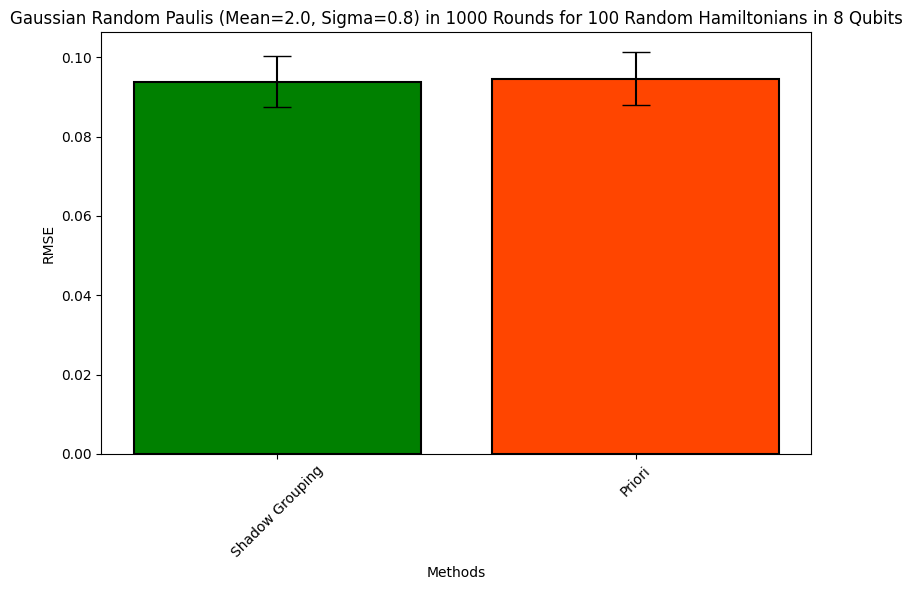

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['Shadow Grouping', 'Priori']
rmse_means = [np.mean(rmse_values_shadow), np.mean(rmse_values_priori)]
rmse_stds = [np.mean(rmse_stds_shadow), np.mean(rmse_stds_priori)]

plt.figure(figsize=(8, 6))
plt.bar(methods, rmse_means, yerr=rmse_stds, capsize=10, color=['green', '#FF4500'], edgecolor='black', linewidth=1.5)
plt.ylabel('RMSE')
plt.xlabel('Methods')
#plt.title(f'Gaussian Random Coefficients (Mean=1.0, Sigma=0.0) in {Nrounds} Rounds for {Nrandom} Random Hamiltonians in {num_qubits[molecule_name]} Qubits')
plt.title(f'Gaussian Random Paulis (Mean=2.0, Sigma=0.8) in {Nrounds} Rounds for {Nrandom} Random Hamiltonians in {num_qubits[molecule_name]} Qubits')
plt.xticks(rotation=45)
plt.ylim(0, None)  # Ensure the y-axis starts at zero
plt.tight_layout()
plt.show()

<h3>Provable Guarantee Plots</h3>

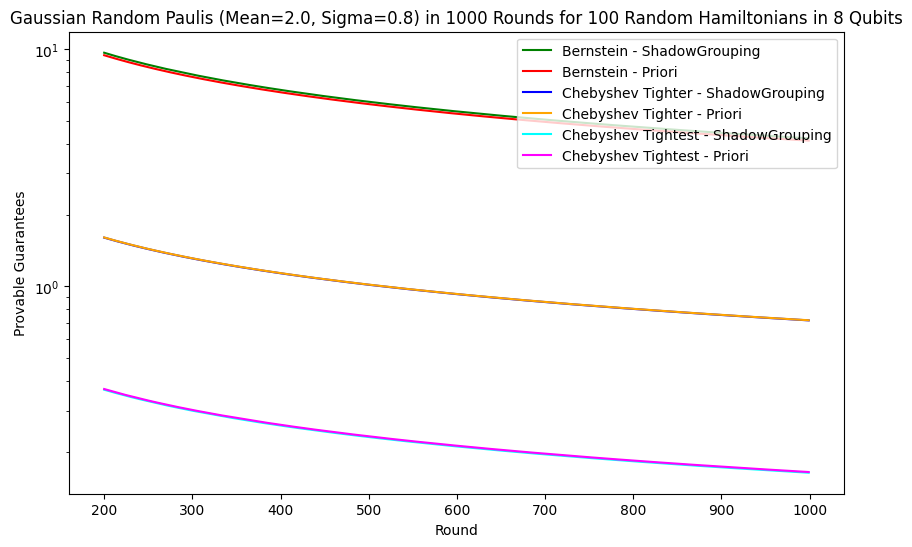

In [ ]:
x = np.arange(Nrounds)
plt.figure(figsize=(10, 6))

start = 200
plt.plot(x[start:], eps_bernstein_avg_shadow[start:], label='Bernstein - ShadowGrouping', color='green')
plt.plot(x[start:], eps_bernstein_avg_priori[start:], label='Bernstein - Priori', color='red')
plt.plot(x[start:], eps_chebyshev_tighter_avg_shadow[start:], label='Chebyshev Tighter - ShadowGrouping', color='blue')
plt.plot(x[start:], eps_chebyshev_tighter_avg_priori[start:], label='Chebyshev Tighter - Priori', color='orange')
plt.plot(x[start:], eps_chebyshev_tightest_avg_shadow[start:], label='Chebyshev Tightest - ShadowGrouping', color='cyan')
plt.plot(x[start:], eps_chebyshev_tightest_avg_priori[start:], label='Chebyshev Tightest - Priori', color='magenta')
plt.yscale('log')
plt.xlabel('Round')
plt.ylabel('Provable Guarantees')
#plt.title(f'Gaussian Random Coefficients (Mean=1.0, Sigma=0.0) in {Nrounds} Rounds for {Nrandom} Random Hamiltonians in {num_qubits[molecule_name]} Qubits')
plt.title(f'Gaussian Random Paulis (Mean=2.0, Sigma=0.8) in {Nrounds} Rounds for {Nrandom} Random Hamiltonians in {num_qubits[molecule_name]} Qubits')
plt.legend()
plt.show()

In [ ]:
# Adding an interrupt to this cell
raise KeyboardInterrupt("Interrupt added for debugging purposes")

KeyboardInterrupt: Interrupt added for debugging purposes

In [ ]:
path = r"D:\priori\generated_data\random_Hamiltonians\Gaussian Random Coefficients (Mean=1, Sigma=0.4) in 1000 Rounds for 100 Random Hamiltonians in 8 Qubits.npz"

with np.load(path) as data:
    print(data.files)
    print("average RMSE for shadow", data['average_rmse_shadow'])
    print("average STD for shadow", data['average_std_shadow'])
    print("average RMSE for priori", data['average_rmse_priori'])
    print("average STD for priori", data['average_std_priori'])

['eps_chebyshev_tighter_avg_shadow', 'eps_chebyshev_tighter_avg_priori', 'eps_bernstein_avg_shadow', 'eps_bernstein_avg_priori', 'eps_chebyshev_tightest_avg_shadow', 'eps_chebyshev_tightest_avg_priori', 'average_rmse_shadow', 'average_std_shadow', 'average_rmse_priori', 'average_std_priori']
average RMSE for shadow 1.8411418685646987
average STD for shadow 0.12359869303860613
average RMSE for priori 1.6239784208249677
average STD for priori 0.11197374555617631


In [ ]:
import sys
import platform

print(f"Python Version: {platform.python_version()}")
print(f"Python Implementation: {platform.python_implementation()}")
print(f"Python Architecture: {platform.architecture()[0]}")
print(f"Python Executable: {sys.executable}")

import os

print(f"Virtual Environment: {os.environ.get('VIRTUAL_ENV', 'Not in a virtual environment')}")

import os
import psutil

process = psutil.Process(os.getpid())
print(f"Memory Usage: {process.memory_info().rss / (1024 ** 2):.2f} MB")

import numpy as np
try:
    np.empty((10000, 10000))  # Adjust size as needed
    print("Large array allocation succeeded.")
except MemoryError:
    print("Large array allocation failed.")

Python Version: 3.11.5
Python Implementation: CPython
Python Architecture: 64bit
Python Executable: d:\priori\.shadowgrouping_env\Scripts\python.exe
Virtual Environment: C:\Users\aebad\shadowgrouping\.shadowgrouping_env
Memory Usage: 225.44 MB
Large array allocation succeeded.


In [ ]:
import numpy as np
a = np.zeros((4096, 4096), dtype=np.complex128)
print("Success")

Success
